# 가설 — 판매자에 따라 지속적으로 갈리는 고객 만족

검증할 가설: **지속적으로 낮은 평가를 받는 판매자가 실재하며, 그 낮은 평가가 약속 위반에서
오는지 아닌지에 따라 처방이 달라진다.**

앞 노트북이 만족을 움직이는 것으로 찾은 것은 약속의 준수 여부였고, 처방도 주문 단위였다 —
들어오는 주문의 예상 도착일을 며칠 미룬다. 누구의 주문인지는 따지지 않는다.
이 가설이 묻는 것은 개입할 대상이 주문이 아니라 **판매자**일 수 있는가이다.

가설이 말하는 것은 둘.

1. 주문이 적어서 흩어진 것이 아니라, 평가가 진짜로 낮은 판매자가 있다
2. 그 낮은 평가가 약속 위반에서 오는지 아닌지에 따라 해야 할 일이 다르다

두 번째가 가르는 것은 문제의 존재가 아니라 처방의 종류다. 배송에서 오는 것이면 그 판매자의
예상 도착일을 더 미루는 것이 처방이고, 약속을 지킨 주문에서도 낮다면 날짜를 미뤄도 소용없어
다른 조치가 필요하다.

고객 만족도는 05 에서 정한 대로 리뷰 점수(1 ~ 5)로 측정. 공용 표본과 축약 규칙도 05 를 따르며
뷰 `order_review` 를 그대로 사용.

**확인 항목**

- 판정 기준 — 무엇이 나오면 성립하고 무엇이 나오면 불성립인가
- 표본 — 05 공용 표본에 더 걸 조건과 그때 빠지는 규모
- 판매자 귀속 규칙 — 한 주문에 판매자가 여럿일 때
- 전용 지표 — 판매자 단위 지표와 흔들림을 가르는 방법

## 0. 연결

05 가 만든 뷰 `order_review` 를 사용하므로 05 실행 이후의 상태가 전제.
처음부터 다시 돌릴 때는 02 로 원본을 복원한 뒤 03 · 04 · 05 순서로 실행.

In [1]:
import duckdb

con = duckdb.connect('../olist.duckdb')
con.execute("SET enable_progress_bar = false");

In [2]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'Malgun Gothic'
rcParams['axes.unicode_minus'] = False
rcParams['figure.dpi'] = 110
rcParams['axes.grid'] = True
rcParams['grid.alpha'] = 0.25
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False

FAST, MID, SLOW = '#3C6E9F', '#D9A05B', '#B3524B'

## 1. 판정 기준

**조건 1 — 지속적으로 낮은 판매자가 실재하는가.**

판매자별 평균 리뷰 점수의 95 % 구간을 잡고 그 상한이 전체 평균보다 낮은 판매자를 센다.
최소 주문 수는 따로 정하지 않는다.

- 성립 — 걸러진 판매자 수가 우연으로 기대되는 수를 뚜렷이 넘고,
  그 판매자들의 주문이 표본에서 무시할 수 없는 비중을 차지한다
- 불성립 — 걸러진 수가 우연으로 기대되는 수와 비슷하거나, 그 주문이 표본에서 차지하는 비중이 아주 작다

같은 점수만 받은 판매자는 정규 근사 구간이 한 점으로 무너지므로,
평균의 구간과 함께 1 ~ 2 점 비율의 Wilson 구간을 본다. 둘 다 나쁜 쪽을 가리킬 때만 판정한다.

**조건 2 — 그 낮은 평가가 약속 위반에서 오는가.**

조건 1 을 통과한 판매자들의 주문 중 약속을 지킨 것만 놓고 같은 구간을 다시 잡는다.

- 배송 밖 요인 — 약속을 지킨 주문에서도 평균이 전체보다 낮게 남는다.
  예상 도착일을 미루는 것으로는 해결되지 않으며 다른 조치가 필요하다
- 배송이 전부 — 약속을 지킨 주문만 보면 평균 근처로 올라온다.
  06 의 시뮬레이션을 이 판매자 집합에만 돌려 크기를 낸다

두 쪽이 섞여 나오면 판매자를 두 무리로 나눠 각각의 규모를 적는다.

## 2. 표본 — 공용 표본에 더 걸 조건

05 의 공용 표본 98,330 건에 이 가설에만 필요한 조건을 더한다.

- **배송 완료** — 조건 2 가 약속 준수 여부를 쓰므로 배송을 겪고 완료 시각이 남은 주문이어야 함
- **품목 기록 있음** — 판매자는 `order_items` 를 거쳐야 알 수 있고, 품목이 없는 주문에는 붙일 수 없음
- **판매자 한 곳** — 한 주문에 판매자가 여럿이면 그 점수를 누구에게 돌릴지 정할 수 없음

조건을 누적해 걸며 남는 행을 집계. 단계마다 줄어드는 폭이 그 조건에서 빠지는 주문의 규모.

In [3]:
con.execute("""
SELECT '1. 공용 표본' AS step,
       COUNT(*)      AS rows
FROM order_review

UNION ALL
SELECT '2. + 배송 완료', COUNT(*)
FROM order_review
WHERE order_status = 'delivered'
  AND order_delivered_customer_date IS NOT NULL

UNION ALL
SELECT '3. + 품목 기록 있음', COUNT(*)
FROM order_review AS o
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
  AND EXISTS (SELECT 1 FROM order_items AS i WHERE i.order_id = o.order_id)

UNION ALL
SELECT '4. + 판매자 한 곳', COUNT(*)
FROM order_review AS o
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
  AND (SELECT COUNT(DISTINCT i.seller_id)
       FROM order_items AS i
       WHERE i.order_id = o.order_id) = 1

ORDER BY step
""").df()

,step,rows
0,1. 공용 표본,98330
1,2. + 배송 완료,95560
2,3. + 품목 기록 있음,95560
3,4. + 판매자 한 곳,94302


공용 표본 98,330 건에서 94,302 건이 남는다. 전체의 95.9 %.

- **배송 미완료 2,770 건** — 배송을 겪지 않아 약속 준수를 물을 수 없는 주문
- **품목 기록 없음 0 건** — 03 에서 품목이 없다고 확인한 주문은 배송된 것이 하나도 없어
  앞 조건에서 이미 전부 빠졌다. 이 조건은 결과적으로 아무것도 걸러내지 않는다
- **판매자 여럿 1,258 건** — 배송 완료분 95,560 건의 1.32 %

판매자가 여럿인 주문을 버리는 선택이 타당한지 규모로 확인한다.
버리는 대신 주문을 판매자마다 복제해 같은 점수를 나눠 붙이는 방법도 있으나,
그러면 한 주문의 점수가 여러 번 계수되고 그 점수를 누가 만들었는지도 알 수 없다.

In [4]:
con.execute("""
WITH base AS (
    SELECT o.order_id
    FROM order_review AS o
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
),
per_order AS (
    SELECT b.order_id,
           COUNT(DISTINCT i.seller_id) AS sellers,
           COUNT(*)                    AS items
    FROM base        AS b
    JOIN order_items AS i ON i.order_id = b.order_id
    GROUP BY b.order_id
)
SELECT sellers,
       COUNT(*)                                           AS orders,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct,
       SUM(items)                                         AS items
FROM per_order
GROUP BY sellers
ORDER BY sellers
""").df()

,sellers,orders,pct,items
0,1,94302,98.68,105997.0
1,2,1199,1.25,2825.0
2,3,54,0.06,202.0
3,4,3,0.00,12.0
4,5,2,0.00,13.0


배송이 완료된 95,560 건 중 판매자가 한 곳인 주문이 94,302 건으로 98.68 %.
둘인 주문이 1,199 건(1.25 %), 셋 54 건, 넷 3 건, 다섯 2 건.

버려지는 것이 1.32 % 라 판매자 귀속 규칙에서 잃는 표본이 거의 없다.
주문을 판매자마다 복제해 점수를 나눠 붙이는 방법을 쓸 이유가 없다.

## 3. 전용 지표

2 의 조건을 적용한 결과를 뷰 `seller_review` 로 고정한다. 주문 하나에 판매자 하나가 붙고,
05 의 점수와 06 이 쓴 약속 대비 값을 함께 담아 조건 2 에서 약속 준수로 나눌 수 있게 한다.

판매자 단위 지표는 셋.

- `orders` — 그 판매자의 주문 수
- `avg_score` — 평균 리뷰 점수. `ci_high` 는 정규 근사 95 % 구간의 상한
- `low_rate` — 1 ~ 2 점 비율. `wilson_low` 는 그 비율의 Wilson 95 % 구간 하한

In [5]:
con.execute("""
CREATE OR REPLACE VIEW seller_review AS
SELECT o.order_id,
       (SELECT MIN(i.seller_id)
        FROM order_items AS i
        WHERE i.order_id = o.order_id) AS seller_id,
       o.customer_state,
       o.order_purchase_timestamp,
       o.delivery_days,
       o.days_vs_promise,
       o.review_score
FROM order_review AS o
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
  AND (SELECT COUNT(DISTINCT i.seller_id)
       FROM order_items AS i
       WHERE i.order_id = o.order_id) = 1
""")

con.execute("""
SELECT COUNT(*)                   AS rows,
       COUNT(DISTINCT order_id)   AS orders,
       COUNT(DISTINCT seller_id)  AS sellers,
       ROUND(AVG(review_score), 4) AS avg_score,
       COUNT(*) FILTER (seller_id IS NULL) AS null_seller
FROM seller_review
""").df()

,rows,orders,sellers,avg_score,null_seller
0,94302,94302,2922,4.1735,0


지표를 판매자마다 계산하고 규모별로 몇 곳이 어느 폭을 갖는지 확인한다.
구간의 폭이 주문 수에 따라 어떻게 줄어드는지가 판정에서 무엇이 걸러질지를 정한다.

In [6]:
con.execute("""
WITH per_seller AS (
    SELECT seller_id,
           COUNT(*)                                              AS orders,
           AVG(review_score)                                     AS avg_score,
           STDDEV_SAMP(review_score)                             AS sd,
           AVG(CASE WHEN review_score <= 2 THEN 1.0 ELSE 0.0 END) AS low_rate
    FROM seller_review
    GROUP BY seller_id
)
SELECT CASE WHEN orders >= 100 THEN '1. 100건 이상'
            WHEN orders >=  50 THEN '2. 50~99건'
            WHEN orders >=  20 THEN '3. 20~49건'
            WHEN orders >=  10 THEN '4. 10~19건'
            WHEN orders >=   5 THEN '5. 5~9건'
            ELSE                    '6. 5건 미만' END              AS bucket,
       COUNT(*)                                                   AS sellers,
       SUM(orders)                                                AS orders,
       ROUND(100.0 * SUM(orders) / SUM(SUM(orders)) OVER (), 2)    AS pct_orders,
       ROUND(AVG(avg_score), 3)                                   AS avg_score,
       ROUND(AVG(1.96 * sd / SQRT(orders)), 3)                     AS avg_ci_halfwidth,
       COUNT(*) FILTER (sd = 0 OR sd IS NULL)                      AS sd_zero
FROM per_seller
GROUP BY bucket
ORDER BY bucket
""").df()

,bucket,sellers,orders,pct_orders,avg_score,avg_ci_halfwidth,sd_zero
0,1. 100건 이상,200,56016.0,59.40,4.160,0.175,0
1,2. 50~99건,208,14650.0,15.54,4.205,0.284,0
2,3. 20~49건,376,11895.0,12.61,4.227,0.420,1
3,4. 10~19건,426,5839.0,6.19,4.218,0.620,1
4,5. 5~9건,520,3513.0,3.73,4.255,0.789,42
5,6. 5건 미만,1192,2389.0,2.53,4.220,1.041,723


뷰 `seller_review` 는 94,302 행에 판매자 2,922 곳, 평균 점수 4.1735.
`seller_id` 가 비는 행은 없다.

**규모가 크게 치우쳐 있다.** 주문 100 건 이상인 판매자가 200 곳뿐인데 그들이 주문의 59.40 % 를
차지하고, 5 건 미만인 판매자는 1,192 곳으로 판매자의 40.8 % 인데 주문은 2.53 % 다.

구간의 반폭이 규모를 그대로 따라간다. 100 건 이상에서 0.175, 50 ~ 99 건 0.284, 20 ~ 49 건 0.420,
10 ~ 19 건 0.620, 5 ~ 9 건 0.789, 5 건 미만 1.041.
전체 평균이 4.17 이므로 100 건 이상인 판매자는 평균이 4.00 아래일 때 상한이 전체 평균을 밑돈다.
반폭이 1 을 넘는 5 건 미만 구간에서는 평균이 3.2 아래여야 걸린다.

**표준편차가 0 인 판매자가 767 곳이다.** 5 건 미만에 723 곳, 5 ~ 9 건에 42 곳, 그 위로 2 곳.
판매자의 26.2 % 가 같은 점수만 받았다는 뜻이고 그들은 정규 근사 구간이 한 점으로 무너진다.
1 에서 Wilson 구간을 함께 두기로 한 이유가 여기서 수치로 확인된다.

판매자를 전부 훑으면 실제로는 낮지 않은 곳도 우연히 걸린다.
2,922 곳을 한쪽 꼬리 2.5 % 로 훑을 때 그렇게 걸리는 수가 약 73 곳이다.

## 4. 조건 1 — 지속적으로 낮은 판매자가 있는가

판매자 단위 지표와 두 판정 플래그를 뷰 `seller_metric` 으로 고정한다.
기준선인 전체 평균과 전체 1 ~ 2 점 비율도 뷰 안에서 표본으로부터 직접 잡으므로
뒤 절에서 같은 계산을 다시 쓰지 않는다.

- `hit_mean` — 평균의 95 % 구간 상한이 전체 평균보다 낮음
- `hit_low` — 1 ~ 2 점 비율의 Wilson 95 % 구간 하한이 전체 1 ~ 2 점 비율보다 높음
- `flagged` — 둘 다. 1 에서 정한 판정 대상

주문이 한 건인 판매자는 표준편차가 없어 `hit_mean` 이 참도 거짓도 아니다.
`flagged` 는 그 경우를 거짓으로 접어 판정에서 뺀다.

In [7]:
con.execute("""
CREATE OR REPLACE VIEW seller_metric AS
WITH base AS (
    SELECT AVG(review_score)                                      AS avg_all,
           AVG(CASE WHEN review_score <= 2 THEN 1.0 ELSE 0.0 END) AS low_all
    FROM seller_review
),
per_seller AS (
    SELECT seller_id,
           COUNT(*)                                           AS orders,
           AVG(review_score)                                  AS avg_score,
           STDDEV_SAMP(review_score)                          AS sd,
           SUM(CASE WHEN review_score <= 2 THEN 1 ELSE 0 END) AS low_n,
           COUNT(*) FILTER (days_vs_promise > 0)              AS late_n
    FROM seller_review
    GROUP BY seller_id
),
calc AS (
    SELECT p.seller_id,
           p.orders,
           p.avg_score,
           p.avg_score + 1.96 * p.sd / SQRT(p.orders) AS ci_high,
           1.0 * p.low_n  / p.orders                  AS low_rate,
           ((1.0 * p.low_n / p.orders + 1.9208 / p.orders)
            - 1.96 * SQRT((1.0 * p.low_n / p.orders)
                          * (1 - 1.0 * p.low_n / p.orders) / p.orders
                          + 0.9604 / (p.orders * p.orders)))
           / (1 + 3.8416 / p.orders)                  AS wilson_low,
           1.0 * p.late_n / p.orders                  AS late_rate,
           b.avg_all,
           b.low_all
    FROM per_seller AS p
    CROSS JOIN base AS b
)
SELECT seller_id, orders, avg_score, ci_high, low_rate, wilson_low, late_rate,
       ci_high    < avg_all AS hit_mean,
       wilson_low > low_all AS hit_low,
       COALESCE(ci_high < avg_all AND wilson_low > low_all, FALSE) AS flagged
FROM calc
""")

con.execute("""
SELECT COUNT(*)                     AS sellers,
       ROUND(MIN(avg_score), 3)     AS min_avg,
       ROUND(MAX(avg_score), 3)     AS max_avg,
       COUNT(*) FILTER (ci_high IS NULL) AS no_interval
FROM seller_metric
""").df()

,sellers,min_avg,max_avg,no_interval
0,2922,1.0,5.0,526


In [8]:
con.execute("""
SELECT '1. 평균 구간 상한이 전체 평균보다 낮음'            AS rule,
       COUNT(*)                                            AS sellers,
       CAST(ROUND(0.025 * (SELECT COUNT(*) FROM seller_metric))
            AS BIGINT)                                     AS chance_max,
       CAST(SUM(orders) AS BIGINT)                         AS orders,
       ROUND(100.0 * SUM(orders)
             / (SELECT SUM(orders) FROM seller_metric), 2) AS pct_orders,
       ROUND(AVG(avg_score), 3)                            AS avg_score
FROM seller_metric WHERE hit_mean

UNION ALL
SELECT '2. Wilson 하한이 전체 1~2점 비율보다 높음',
       COUNT(*),
       CAST(ROUND(0.025 * (SELECT COUNT(*) FROM seller_metric)) AS BIGINT),
       CAST(SUM(orders) AS BIGINT),
       ROUND(100.0 * SUM(orders) / (SELECT SUM(orders) FROM seller_metric), 2),
       ROUND(AVG(avg_score), 3)
FROM seller_metric WHERE hit_low

UNION ALL
SELECT '3. 둘 다 — 판정 대상',
       COUNT(*),
       CAST(ROUND(0.025 * (SELECT COUNT(*) FROM seller_metric)) AS BIGINT),
       CAST(SUM(orders) AS BIGINT),
       ROUND(100.0 * SUM(orders) / (SELECT SUM(orders) FROM seller_metric), 2),
       ROUND(AVG(avg_score), 3)
FROM seller_metric WHERE flagged

ORDER BY rule
""").df()

,rule,sellers,chance_max,orders,pct_orders,avg_score
0,1. 평균 구간 상한이 전체 평균보다 낮음,130,73,16188,17.17,3.155
1,2. Wilson 하한이 전체 1~2점 비율보다 높음,226,73,16142,17.12,2.577
2,3. 둘 다 — 판정 대상,94,73,13700,14.53,3.068


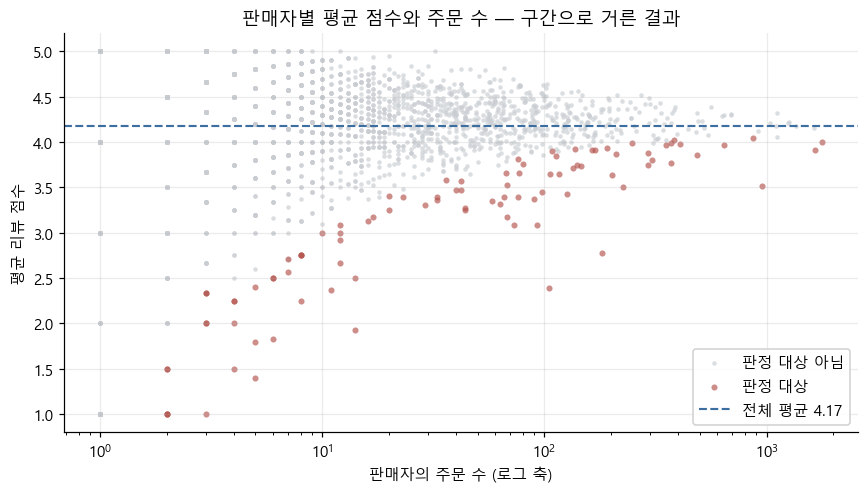

In [9]:
d = con.execute("SELECT orders, avg_score, flagged FROM seller_metric ORDER BY flagged").df()
base = con.execute("SELECT AVG(review_score) FROM seller_review").fetchone()[0]

fig, ax = plt.subplots(figsize=(8, 4.6))
for keep, color, size, label in [(False, '#C9CDD2', 9, '판정 대상 아님'),
                                 (True, SLOW, 16, '판정 대상')]:
    s = d[d['flagged'] == keep]
    ax.scatter(s['orders'], s['avg_score'], s=size, c=color, alpha=0.65,
               linewidths=0, label=label)
ax.axhline(base, color=FAST, lw=1.4, ls='--', label=f'전체 평균 {base:.2f}')
ax.set_xscale('log')
ax.set_xlabel('판매자의 주문 수 (로그 축)')
ax.set_ylabel('평균 리뷰 점수')
ax.set_title('판매자별 평균 점수와 주문 수 — 구간으로 거른 결과')
ax.legend(loc='lower right', framealpha=0.9)
plt.tight_layout()
plt.show()

평균의 구간으로 130 곳, Wilson 구간으로 226 곳이 걸리고 둘 다 걸린 판매자가 94 곳이다.
이 94 곳이 1 에서 정한 판정 대상이며 주문 13,700 건으로 표본의 14.53 % 를 차지한다.

`chance_max` 는 판매자가 실제로는 낮지 않은데 구간이 우연히 아래로 떨어져 걸리는 수다.
2,922 곳을 한쪽 꼬리 2.5 % 로 훑으면 그런 판매자가 73 곳 나온다. 두 기준을 함께 요구하면
그보다 줄어드므로 73 은 우연만으로 걸릴 수 있는 최대치다. 94 곳은 그 최대치보다 많지만 1.3 배에 그쳐,
전체 수만으로는 우연과 실체를 가르기 어렵다. 규모별로 나눠 봐야 한다.

Wilson 단독이 226 곳으로 가장 많은 것은 주문이 한 건인 판매자 때문이다. 1 점을 한 건 받으면
Wilson 하한이 0.207 로 전체 1 ~ 2 점 비율 0.123 을 넘는다. 평균의 구간은 주문이 한 건이면
표준편차가 없어 잡히지 않고, 그런 판매자가 526 곳이다. `flagged` 가 두 기준을 함께 요구하면서
그 526 곳이 판정에서 빠진다.

In [10]:
con.execute("""
SELECT CASE WHEN orders >= 100 THEN '1. 100건 이상'
            WHEN orders >=  50 THEN '2. 50~99건'
            WHEN orders >=  20 THEN '3. 20~49건'
            WHEN orders >=  10 THEN '4. 10~19건'
            WHEN orders >=   5 THEN '5. 5~9건'
            ELSE                    '6. 5건 미만' END         AS bucket,
       COUNT(*)                                               AS sellers,
       COUNT(*) FILTER (flagged)                              AS flagged,
       ROUND(100.0 * COUNT(*) FILTER (flagged) / COUNT(*), 1) AS flagged_pct,
       CAST(SUM(orders) FILTER (flagged) AS BIGINT)           AS flagged_orders,
       ROUND(AVG(avg_score) FILTER (flagged), 3)              AS flagged_avg,
       ROUND(AVG(avg_score) FILTER (NOT flagged), 3)          AS rest_avg
FROM seller_metric
GROUP BY bucket
ORDER BY bucket
""").df()

,bucket,sellers,flagged,flagged_pct,flagged_orders,flagged_avg,rest_avg
0,1. 100건 이상,200,32,16.0,11992,3.749,4.239
1,2. 50~99건,208,14,6.7,1052,3.432,4.260
2,3. 20~49건,376,12,3.2,406,3.395,4.254
3,4. 10~19건,426,10,2.3,130,2.776,4.252
4,5. 5~9건,520,12,2.3,79,2.352,4.300
5,6. 5건 미만,1192,14,1.2,41,1.690,4.250


**초과분이 큰 판매자 쪽에 몰려 있다.** 주문 100 건 이상인 200 곳 중 32 곳(16.0 %)이 걸렸다.
우연이라면 2.5 % 인 5 곳이어야 하므로 6.4 배다. 50 ~ 99 건에서 6.7 %, 20 ~ 49 건에서 3.2 % 로
내려가고, 10 건 미만에서는 2.3 % 와 1.2 % 로 우연 수준이거나 그 아래다.

우연으로 걸리는 판매자라면 구간이 넓은 작은 쪽에 쏠려야 한다. 결과는 반대다. 구간이 좁아
우연히 걸리기 어려운 쪽에서 초과분이 나오고, 작은 쪽에는 초과분이 없다.
걸린 주문 13,700 건 중 11,992 건(87.5 %)이 100 건 이상 판매자에게서 나온다.

걸리지 않은 판매자의 평균은 어느 규모에서나 4.24 ~ 4.30 으로 붙어 있다. 걸린 판매자의 평균은
100 건 이상에서 3.749 이고 5 건 미만에서 1.690 이다. 작은 쪽의 1.690 은 두세 건이 낮게 나온 값이고,
큰 쪽의 3.749 는 11,992 건 위에서 나온 값이다.

**조건 1 성립.** 지속적으로 낮은 평가를 받는 판매자가 실재한다. 94 곳, 주문 13,700 건으로
표본의 14.53 %. 증거의 무게는 주문 100 건 이상인 32 곳에 실려 있다.

## 5. 조건 2 — 그 낮은 평가가 약속 위반에서 오는가

판정 대상과 나머지를 약속 준수 여부로 갈라 네 칸으로 본다. 두 무리의 평균 격차가
위반을 더 자주 겪어서 생긴 것인지, 같은 조건 안에서도 낮아서 생긴 것인지를 한 표에서 읽는다.

In [11]:
con.execute("""
WITH g AS (
    SELECT s.review_score, s.days_vs_promise,
           CASE WHEN m.flagged THEN '1. 판정 대상' ELSE '2. 나머지' END AS grp
    FROM seller_review AS s JOIN seller_metric AS m USING (seller_id)
)
SELECT grp,
       COUNT(*)                                                           AS orders,
       ROUND(AVG(review_score), 3)                                        AS avg_score,
       ROUND(100.0 * COUNT(*) FILTER (days_vs_promise > 0) / COUNT(*), 2) AS late_pct,
       ROUND(AVG(review_score) FILTER (days_vs_promise <= 0), 3)          AS avg_kept,
       ROUND(AVG(review_score) FILTER (days_vs_promise >  0), 3)          AS avg_late
FROM g GROUP BY grp ORDER BY grp
""").df()

,grp,orders,avg_score,late_pct,avg_kept,avg_late
0,1. 판정 대상,13700,3.773,9.58,3.955,2.050
1,2. 나머지,80602,4.242,6.27,4.369,2.329


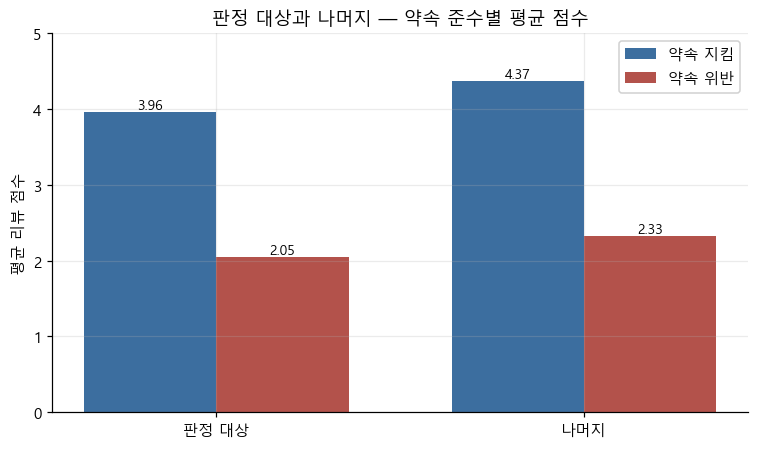

In [12]:
d = con.execute("""
WITH g AS (
    SELECT s.review_score, s.days_vs_promise,
           CASE WHEN m.flagged THEN '1. 판정 대상' ELSE '2. 나머지' END AS grp
    FROM seller_review AS s JOIN seller_metric AS m USING (seller_id)
)
SELECT grp,
       AVG(review_score) FILTER (days_vs_promise <= 0) AS kept,
       AVG(review_score) FILTER (days_vs_promise >  0) AS late
FROM g GROUP BY grp ORDER BY grp
""").df()

x, w = range(len(d)), 0.36
fig, ax = plt.subplots(figsize=(7, 4.2))
b1 = ax.bar([i - w/2 for i in x], d['kept'], w, color=FAST, label='약속 지킴')
b2 = ax.bar([i + w/2 for i in x], d['late'], w, color=SLOW, label='약속 위반')
for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.04,
            f'{b.get_height():.2f}', ha='center', fontsize=9)
ax.set_xticks(list(x)); ax.set_xticklabels([s[3:] for s in d['grp']])
ax.set_ylim(0, 5); ax.set_ylabel('평균 리뷰 점수')
ax.set_title('판정 대상과 나머지 — 약속 준수별 평균 점수')
ax.legend(loc='upper right', framealpha=0.9)
plt.tight_layout(); plt.show()

판정 대상 94 곳의 주문 13,700 건은 평균 3.773, 나머지 80,602 건은 4.242 다. 격차 0.469.
주문 수로 가중한 값이라 판매자별 평균을 그대로 평균한 3.068 과 다르다.

약속 위반율은 판정 대상 9.58 %, 나머지 6.27 % 로 1.53 배다. 더 자주 늦는 것은 맞다.
그런데 약속을 지킨 주문만 보면 3.955 대 4.369 로 0.414 가 남고, 위반한 주문만 보아도
2.050 대 2.329 로 낮다. 네 칸 어디에서도 낮으므로 격차가 위반 비중만으로 설명되지 않는다.

In [13]:
con.execute("""
WITH g AS (
    SELECT s.review_score,
           CASE WHEN m.flagged THEN 'F' ELSE 'R' END AS grp,
           CASE WHEN s.days_vs_promise > 0 THEN '2. 약속 위반' ELSE '1. 약속 지킴' END AS cond
    FROM seller_review AS s JOIN seller_metric AS m USING (seller_id)
),
cel AS (SELECT grp, cond, COUNT(*) AS n, AVG(review_score) AS m FROM g GROUP BY grp, cond),
sh  AS (SELECT grp, cond, m, 1.0 * n / SUM(n) OVER (PARTITION BY grp) AS share FROM cel),
j   AS (SELECT f.cond, f.share AS sf, f.m AS mf, r.share AS sr, r.m AS mr
        FROM (SELECT * FROM sh WHERE grp = 'F') AS f
        JOIN (SELECT * FROM sh WHERE grp = 'R') AS r USING (cond))
SELECT '1. 판정 대상과 나머지의 평균 격차' AS item,
       ROUND(SUM(sf*mf) - SUM(sr*mr), 4)   AS value,
       CAST(100.0 AS DOUBLE)               AS pct
FROM j
UNION ALL
SELECT '2. 약속 위반 비중 차이의 몫', ROUND(SUM((sf-sr)*mr), 4),
       ROUND(100.0 * SUM((sf-sr)*mr) / (SUM(sf*mf) - SUM(sr*mr)), 1) FROM j
UNION ALL
SELECT '3. 같은 조건 안 점수 차이의 몫', ROUND(SUM(sf*(mf-mr)), 4),
       ROUND(100.0 * SUM(sf*(mf-mr)) / (SUM(sf*mf) - SUM(sr*mr)), 1) FROM j
ORDER BY item
""").df()

,item,value,pct
0,1. 판정 대상과 나머지의 평균 격차,-0.4687,100.0
1,2. 약속 위반 비중 차이의 몫,-0.0676,14.4
2,3. 같은 조건 안 점수 차이의 몫,-0.4011,85.6


격차 0.469 중 위반 비중 차이가 만든 몫은 0.068 로 14.4 %,
같은 조건 안에서 벌어진 몫이 0.401 로 85.6 % 다.

판정 대상을 나머지와 같은 위반율로 되돌려도 격차의 다섯 중 넷 이상이 남는다.
예상 도착일을 미루는 처방이 겨냥하는 것은 14.4 % 다.

분해가 낸 85.6 % 가 판정 대상을 고른 규칙과 얼마나 떨어져 있는지 확인한다.

조건 1 은 평균이 낮은 판매자를 고르는 규칙이므로 걸린 판매자의 평균이 낮은 것은 규칙이 정한 것이고,
남는 질문은 그 낮은 평균이 위반을 자주 겪어서 생길 수 있었는가다.
판정 대상이 약속 준수별로 나머지와 똑같은 점수를 받는다고 두고,
위반율이 얼마여야 평균이 그만큼 내려가는지 역산한다.

In [14]:
con.execute("""
WITH cel AS (
    SELECT AVG(s.review_score) FILTER (s.days_vs_promise <= 0) AS m_kept,
           AVG(s.review_score) FILTER (s.days_vs_promise >  0) AS m_late
    FROM seller_review AS s
    JOIN seller_metric AS m USING (seller_id)
    WHERE NOT m.flagged
),
tgt AS (
    SELECT (SELECT AVG(review_score) FROM seller_review)  AS avg_all,
           AVG(s.review_score)                            AS avg_flagged,
           1.0 * COUNT(*) FILTER (s.days_vs_promise > 0)
               / COUNT(*)                                 AS late_flagged
    FROM seller_review AS s
    JOIN seller_metric AS m USING (seller_id)
    WHERE m.flagged
)
SELECT '1. 전체 평균까지 내려가는 데 필요한 위반율'         AS item,
       ROUND(100.0 * (c.m_kept - t.avg_all)
                   / (c.m_kept - c.m_late), 2)              AS late_pct,
       ROUND(t.avg_all, 3)                                  AS avg_at_rate
FROM cel AS c CROSS JOIN tgt AS t

UNION ALL
SELECT '2. 판정 대상의 평균까지 내려가는 데 필요한 위반율',
       ROUND(100.0 * (c.m_kept - t.avg_flagged)
                   / (c.m_kept - c.m_late), 2),
       ROUND(t.avg_flagged, 3)
FROM cel AS c CROSS JOIN tgt AS t

UNION ALL
SELECT '3. 판정 대상의 실제 위반율',
       ROUND(100.0 * t.late_flagged, 2),
       ROUND(c.m_kept - t.late_flagged * (c.m_kept - c.m_late), 3)
FROM cel AS c CROSS JOIN tgt AS t

ORDER BY item
""").df()

,item,late_pct,avg_at_rate
0,1. 전체 평균까지 내려가는 데 필요한 위반율,9.61,4.173
1,2. 판정 대상의 평균까지 내려가는 데 필요한 위반율,29.24,3.773
2,3. 판정 대상의 실제 위반율,9.58,4.174


나머지와 같은 점수를 받으면서 전체 평균 4.174 아래로 내려가려면 위반율이 9.61 % 를 넘어야 한다.
판정 대상의 실제 위반율은 9.58 % 로 그 문턱에 걸쳐 있고, 그 위반율에서 기대되는 평균은 4.174 로
전체 평균과 같다. 실제 평균은 3.773 이다.

**조건 1 이 고른 것은 위반이 잦은 판매자가 아니라 약속을 지킨 주문에서 낮은 판매자다.**
위반은 판정 대상 주문의 9.58 % 뿐이라 나머지 90.42 % 에서 낮지 않고는 평균이 문턱 아래로
내려가지 않는다. 위반만으로 실제 평균 3.773 에 닿으려면 위반율이 29.24 % 여야 한다.
같은 조건 안 차이가 85.6 % 로 나오는 것은 이 선별 규칙에서 상당 부분 따라 나온다.

분해가 더하는 것은 격차의 방향이 아니라 크기다. 위반율을 나머지와 같게 되돌려도 0.401 이 남는다.

In [15]:
con.execute("""
CREATE OR REPLACE VIEW seller_verdict AS
WITH base AS (
    SELECT AVG(review_score) AS avg_kept_all
    FROM seller_review
    WHERE days_vs_promise <= 0
),
ps AS (
    SELECT seller_id,
           COUNT(*)          FILTER (days_vs_promise <= 0) AS n_kept,
           AVG(review_score) FILTER (days_vs_promise <= 0) AS m_kept,
           STDDEV_SAMP(review_score)
                             FILTER (days_vs_promise <= 0) AS sd_kept,
           COUNT(*)          FILTER (days_vs_promise >  0) AS n_late,
           AVG(review_score) FILTER (days_vs_promise >  0) AS m_late
    FROM seller_review
    GROUP BY seller_id
),
j AS (
    SELECT m.*,
           p.n_kept, p.m_kept, p.sd_kept, p.n_late, p.m_late,
           p.m_kept + 1.96 * p.sd_kept / SQRT(p.n_kept) AS ci_high_kept,
           b.avg_kept_all
    FROM seller_metric AS m
    JOIN ps            AS p USING (seller_id)
    CROSS JOIN base    AS b
)
SELECT *,
       CASE WHEN NOT flagged                       THEN NULL
            WHEN n_kept = 0                        THEN '4. 약속 지킨 주문 없음'
            WHEN ci_high_kept < avg_kept_all       THEN '1. 약속을 지켜도 낮음'
            WHEN m_kept       < avg_kept_all       THEN '2. 낮은 쪽이나 구간이 걸침'
            ELSE                                        '3. 약속을 지키면 낮지 않음' END AS verdict
FROM j
""")

con.execute("""
SELECT verdict,
       COUNT(*)                                         AS sellers,
       CAST(SUM(orders) AS BIGINT)                      AS orders,
       ROUND(AVG(avg_score), 3)                         AS avg_all_orders,
       ROUND(AVG(m_kept), 3)                            AS avg_kept_orders,
       ROUND(100.0 * AVG(late_rate), 2)                 AS late_pct,
       COUNT(*) FILTER (sd_kept IS NULL OR sd_kept = 0) AS no_spread,
       ROUND(MIN(avg_kept_all), 3)                      AS base_kept
FROM seller_verdict
WHERE flagged
GROUP BY verdict
ORDER BY verdict
""").df()

,verdict,sellers,orders,avg_all_orders,avg_kept_orders,late_pct,no_spread,base_kept
0,1. 약속을 지켜도 낮음,62,12049,3.219,3.374,10.58,0,4.311
1,2. 낮은 쪽이나 구간이 걸침,28,1215,2.766,3.204,31.46,5,4.311
2,3. 약속을 지키면 낮지 않음,3,434,3.280,4.373,37.31,0,4.311
3,4. 약속 지킨 주문 없음,1,2,1.500,NaN,100.00,1,4.311


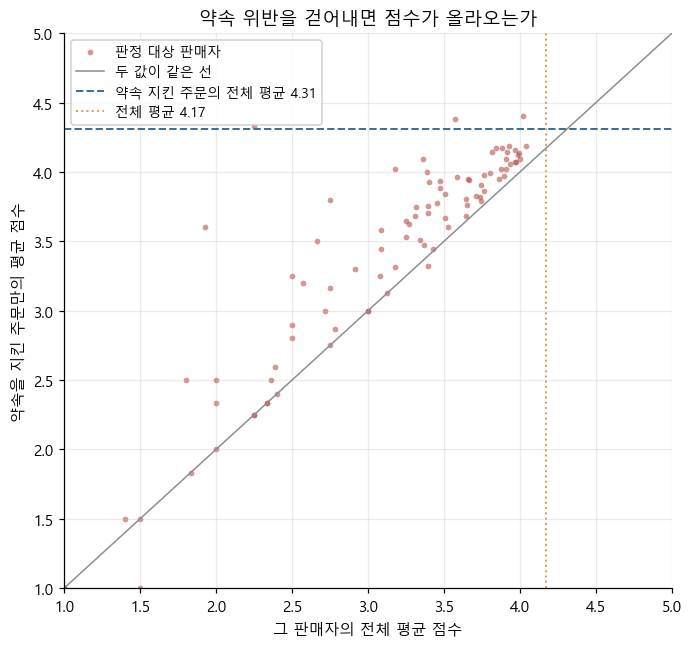

In [16]:
d = con.execute("""
SELECT seller_id, avg_score, m_kept
FROM seller_verdict
WHERE flagged AND m_kept IS NOT NULL
""").df()

base_all  = con.execute("SELECT AVG(review_score) FROM seller_review").fetchone()[0]
base_kept = con.execute("SELECT MIN(avg_kept_all) FROM seller_verdict").fetchone()[0]

fig, ax = plt.subplots(figsize=(6.4, 6.0))
ax.scatter(d['avg_score'], d['m_kept'], s=14, c=SLOW, alpha=0.6, linewidths=0,
           label='판정 대상 판매자')
ax.plot([1, 5], [1, 5], color='#8A8F94', lw=1.0, label='두 값이 같은 선')
ax.axhline(base_kept, color=FAST, lw=1.3, ls='--',
           label=f'약속 지킨 주문의 전체 평균 {base_kept:.2f}')
ax.axvline(base_all, color=MID, lw=1.3, ls=':', label=f'전체 평균 {base_all:.2f}')
ax.set_xlim(1, 5); ax.set_ylim(1, 5)
ax.set_xlabel('그 판매자의 전체 평균 점수')
ax.set_ylabel('약속을 지킨 주문만의 평균 점수')
ax.set_title('약속 위반을 걷어내면 점수가 올라오는가')
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
plt.tight_layout(); plt.show()

판매자마다 다시 판정하면 94 곳이 넷으로 나뉜다. 기준은 약속을 지킨 주문의 전체 평균 4.311.

- **약속을 지켜도 낮음 62 곳, 주문 12,049 건.** 3.219 가 약속 지킨 주문만 보아도 3.374 로
  0.155 만 오른다. 4.311 과는 여전히 멀고 위반율도 10.58 % 로 판정 대상 평균 언저리다
- **낮은 쪽이나 구간이 걸침 28 곳, 주문 1,215 건.** 2.766 에서 3.204 로 오르지만 4.311 에 못 미친다.
  판매자당 주문이 43 건이라 구간이 넓어 단정하지 못하는 쪽이지 평균으로 올라온 쪽이 아니다
- **약속을 지키면 낮지 않음 3 곳, 주문 434 건.** 3.280 이 4.373 으로 올라 기준을 넘는다.
  위반율 37.31 % 로 판정 대상 평균의 네 배다
- **약속 지킨 주문 없음 1 곳, 주문 2 건**

산점도에서 점 대부분이 같은 값 선에서 조금 위에 있다. 위반을 걷어내도 점수가 거의 그대로라는 뜻이다.
오른쪽 위로 크게 올라간 점 셋이 세 번째 무리다.

**조건 2 — 두 쪽이 섞였고 한쪽이 압도적이다.** 배송 밖 요인이 62 곳(주문 12,049 건,
판정 대상 주문의 88.0 %), 배송이 전부인 쪽이 3 곳(434 건, 3.2 %).

## 6. 정리

**표본과 지표**

- **표본 94,302 건.** 05 공용 표본 98,330 건에 배송 완료 · 판매자 한 곳을 더한 것.
  공용 표본의 95.9 % 가 남고 판매자 귀속 규칙에서 잃는 것은 1.32 %
- **판매자 2,922 곳.** 주문 100 건 이상인 200 곳이 주문의 59.4 % 를 차지하고
  5 건 미만인 1,192 곳이 2.53 % 를 나눠 가짐
- **뷰 셋.** `seller_review` 가 주문 · 판매자 · 점수와 배송 소요일 · 약속 대비를 담고,
  `seller_metric` 이 판매자 단위 지표와 두 판정 플래그를,
  `seller_verdict` 가 약속 준수로 나눈 값과 조건 2 의 판정을 담음

**조건 1 — 성립**

- 두 기준에 함께 걸린 판매자 94 곳, 주문 13,700 건으로 표본의 14.53 %
- 전체 수 94 는 우연만으로 걸릴 수 있는 최대치 73 의 1.3 배에 그치지만 초과분이 구간이 좁은 큰 판매자에 몰려 있다.
  100 건 이상 200 곳 중 32 곳(16.0 %)이 걸려 우연 기대치 2.5 % 의 6.4 배이고,
  10 건 미만에서는 우연 수준이거나 그 아래

**조건 2 — 두 쪽이 섞였고 배송 밖 요인이 압도적**

- 격차 0.469 중 위반 비중 차이의 몫이 14.4 %, 같은 조건 안 점수 차이가 85.6 %
- 판매자별로는 네 무리. 약속을 지켜도 낮은 62 곳(주문 12,049 건, 판정 대상 주문의 88.0 %),
  낮은 쪽이나 구간이 걸쳐 판정을 유보한 28 곳(1,215 건, 8.9 %),
  약속을 지키면 낮지 않은 3 곳(434 건, 3.2 %), 약속을 지킨 주문이 없는 1 곳(2 건)
- 유보한 28 곳을 어느 쪽으로 넣어도 결론이 뒤집히지 않는다. 62 곳에 넣으면 배송 밖 요인이
  판정 대상 주문의 96.8 % 가 되고, 3 곳에 넣어도 배송이 전부인 쪽은 12.0 % 에 그친다

**제안**

- **패딩은 이 문제의 처방이 아니다.** 판정 대상 94 곳 중 날짜를 미뤄 해결되는 곳은 3 곳,
  주문 434 건으로 표본의 0.46 % 다. 나머지는 약속을 지킨 주문에서도 낮게 남아 날짜로 움직이지 않는다
- **그 3 곳에는 정확히 듣는다.** 위반율이 37.31 % 로 판정 대상 평균의 네 배이고
  위반을 걷어내면 4.373 으로 기준을 넘는다. 규모가 작아 전체 효과는 크지 않다
- **패딩을 판매자로 겨냥하면 효율이 조금 오른다.** 판정 대상의 주문은 표본의 14.53 % 인데
  전체 위반 6,366 건 중 1,312 건(20.6 %)이 여기서 나온다. 같은 날짜를 미루고 위반을 더 걷는다
- **62 곳에는 날짜가 아닌 다른 조치가 필요하다.** 약속을 지켜도 낮게 남는 주문 12,049 건이
  여기 있다. 판정 대상 주문의 88.0 % 이자 표본의 12.78 %
- **유보한 28 곳은 주문이 더 쌓여야 갈린다.** 판매자당 43 건이라 약속을 지킨 주문만 남기면
  구간이 기준선을 걸친다. 평균은 3.204 로 낮은 쪽이나 62 곳과 함께 묶기에는 근거가 모자란다

## 7. 이 분석이 답하지 못하는 것

**격차의 85.6 % 가 선별 방식과 무관한 결과인가.** 아니다.
조건 1 은 평균이 낮은 판매자를 고르는 규칙이고 위반은 그 주문의 9.58 % 뿐이라,
약속을 지킨 주문에서 낮지 않고는 걸릴 수 없다. 방향은 규칙에서 따라 나오고 분해가 더하는 것은
크기다. 다만 선별이 답을 끝까지 정하지는 않는다. 약속을 지킨 주문만의 평균이 4.311 에 닿는지는
평균 전체로 고르는 것과 다른 비교이고, 94 곳 중 3 곳이 그쪽으로 갈렸다.

**62 곳이 왜 낮은 평가를 받는가.** 확인 불가.
표본에 주문 · 배송 · 점수만 있어 무엇이 낮은 평가를 만드는지 가리지 못한다.

**이 판매자들이 다른 기간에도 낮은가.** 확인 불가.
94 곳을 고른 표본과 그 판매자를 판정한 표본이 같다. 한 표본에서 낮게 나온 것을 같은 표본으로
다시 판정한 값이므로, 다음 기간에도 낮게 나오는지는 이 표본 밖의 문제다.

**28 곳이 어느 쪽인가.** 확인 불가.
주문 1,215 건에 판매자당 43 건이라 약속을 지킨 주문만 남기면 구간이 기준선 4.311 을 걸친다.
평균 3.204 는 낮은 쪽이나 구간이 갈라주지 않는다. 어느 쪽에 넣어도 배송 밖 요인이
판정 대상 주문의 88.0 ~ 96.8 % 라 결론은 갈리지 않는다.

## 8. 내보내기

Tableau 는 DuckDB 에 직접 붙지 못하므로 판매자 단위 한 장을 파일로 뽑는다.
판정 플래그와 4 분류, 약속 준수로 나눈 건수와 평균까지 담아
산점도 · 규모 구간 · 약속 준수별 비교를 파일 하나에서 다시 만들 수 있게 한다.

내보낸 파일을 다시 읽어 5 의 약속 준수별 평균이 그대로 나오는지 대조.

In [17]:
import os

os.makedirs('../exports', exist_ok=True)

con.execute("""
COPY (
    SELECT seller_id,
           orders,
           CASE WHEN orders >= 100 THEN '1. 100건 이상'
                WHEN orders >=  50 THEN '2. 50~99건'
                WHEN orders >=  20 THEN '3. 20~49건'
                WHEN orders >=  10 THEN '4. 10~19건'
                WHEN orders >=   5 THEN '5. 5~9건'
                ELSE                    '6. 5건 미만' END AS bucket,
           ROUND(avg_score,  4)                   AS avg_score,
           ROUND(ci_high,    4)                   AS ci_high,
           ROUND(low_rate,   4)                   AS low_rate,
           ROUND(wilson_low, 4)                   AS wilson_low,
           ROUND(late_rate,  4)                   AS late_rate,
           hit_mean,
           hit_low,
           flagged,
           COALESCE(verdict, '0. 판정 대상 아님')  AS verdict,
           n_kept,
           ROUND(m_kept, 4)                       AS avg_kept,
           n_late,
           ROUND(m_late, 4)                       AS avg_late,
           ROUND(avg_kept_all, 4)                 AS base_kept
    FROM seller_verdict
    ORDER BY orders DESC, seller_id
) TO '../exports/07_seller_metric.csv' (HEADER, DELIMITER ',')
""")

con.execute("""
WITH f AS (SELECT * FROM read_csv_auto('../exports/07_seller_metric.csv'))
SELECT '1. 판정 대상'                               AS grp,
       COUNT(*)                                     AS sellers,
       CAST(SUM(orders) AS BIGINT)                  AS orders,
       ROUND(SUM(avg_kept * n_kept) / SUM(n_kept), 3) AS avg_kept,
       ROUND(SUM(avg_late * n_late) / SUM(n_late), 3) AS avg_late
FROM f WHERE flagged

UNION ALL
SELECT '2. 나머지', COUNT(*), CAST(SUM(orders) AS BIGINT),
       ROUND(SUM(avg_kept * n_kept) / SUM(n_kept), 3),
       ROUND(SUM(avg_late * n_late) / SUM(n_late), 3)
FROM f WHERE NOT flagged

ORDER BY grp
""").df()

,grp,sellers,orders,avg_kept,avg_late
0,1. 판정 대상,94,13700,3.955,2.050
1,2. 나머지,2828,80602,4.369,2.329


## 9. 연결 종료

DuckDB 파일은 한 프로세스만 쓰기 모드로 열 수 있으므로 다음 노트북을 위해 여기서 종료.
뷰 `seller_review` · `seller_metric` · `seller_verdict` 는 DB 파일에 저장되어 연결을 닫아도 유지.

In [18]:
con.close()